In [1]:
%pip install watermark
%pip install vaderSentiment
%pip install imbalanced-learn
%pip install wordcloud
%pip install lightgbm


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import of libraries

# System libraries
import re
import unicodedata
import itertools
from datasets import Dataset

# Library for file manipulation
import pandas as pd
import numpy as np
import pandas

# Data visualization
import seaborn as sns
import matplotlib.pylab as pl
import matplotlib as m
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import pyplot as plt

# ML NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

### Download the necessary resources from nltk (tokenizers and stopwords corpus)
# Punkt tokenizer for word tokenization
nltk.download('punkt')

# Stopwords list in multiple languages
nltk.download('stopwords') 

# Configuration for graph width and layout
sns.set_theme(style='whitegrid')
palette='viridis'

# Warnings remove alerts
import warnings
warnings.filterwarnings("ignore")

# Python version
from platform import python_version
print('Python version in this Jupyter Notebook:', python_version())

# Load library versions
import watermark

# Library versions
%reload_ext watermark
%watermark -a "Library versions" --iversions

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mohitkarjee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohitkarjee/nltk_data...


Python version in this Jupyter Notebook: 3.11.4
Author: Library versions

seaborn   : 0.12.2
matplotlib: 3.7.1
nltk      : 3.8.1
plotly    : 5.9.0
pandas    : 2.2.3
platform  : 1.0.8
re        : 2.2.1
numpy     : 1.24.3
datasets  : 2.12.0
watermark : 2.5.0



[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# Database
pd.set_option('display.max_columns', None)
df = pd.read_csv("7817_1.csv")

# Viewing dataset
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,manufacturer,manufacturerNumber,name,prices,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-08-08T00:00:00.000Z,NaN,139.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-09-01T00:00:00.000Z,NaN,126.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-07-20T00:00:00.000Z,NaN,69.0,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2017-06-16T00:00:00.000Z,NaN,2.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2016-08-11T00:00:00.000Z,NaN,17.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [4]:
# Viewing first 5 data
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,manufacturer,manufacturerNumber,name,prices,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-08-08T00:00:00.000Z,NaN,139.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-09-01T00:00:00.000Z,NaN,126.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-07-20T00:00:00.000Z,NaN,69.0,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2017-06-16T00:00:00.000Z,NaN,2.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2016-08-11T00:00:00.000Z,NaN,17.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [5]:
# Info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [6]:
# Type data
df.dtypes

id                       object
asins                    object
brand                    object
categories               object
colors                   object
dateAdded                object
dateUpdated              object
dimension                object
ean                     float64
keys                     object
manufacturer             object
manufacturerNumber       object
name                     object
prices                   object
reviews.date             object
reviews.doRecommend      object
reviews.numHelpful      float64
reviews.rating          float64
reviews.sourceURLs       object
reviews.text             object
reviews.title            object
reviews.userCity        float64
reviews.userProvince    float64
reviews.username         object
sizes                   float64
upc                     float64
weight                   object
dtype: object

In [7]:
# Viewing rows and columns
df.shape

(1597, 27)

In [8]:
# Copy data
data = df.copy()

In [9]:
print("Checking for missing values in each column:")
print(df.isnull().sum())

Checking for missing values in each column:
id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64


In [10]:
# Remove columns that have any NaN value
df = df.dropna(axis=1)

# Check remaining columns after removal
print("Remaining columns after removing columns with NaN:")
print(df.isnull().sum())

Remaining columns after removing columns with NaN:
id                    0
asins                 0
brand                 0
categories            0
dateAdded             0
dateUpdated           0
keys                  0
name                  0
prices                0
reviews.sourceURLs    0
reviews.text          0
dtype: int64


In [11]:
%%time

import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

### Download the necessary resources from nltk (tokenizers and stopwords corpus)
# Punkt tokenizer for word tokenization
nltk.download('punkt')
 
# Stopwords list in multiple languages
nltk.download('stopwords')   

# Initialize the Porter stemmer and load English stopwords
stemmer = PorterStemmer()

# Create a set of English stopwords for efficient lookup
stop_words = set(stopwords.words('english'))  

# Function to clean the text by removing URLs, handles, and punctuation
def clean_text(text):
    if isinstance(text, str):
        # Convert text to lowercase
        text = text.lower()

        # Remove URLs (http, https, and www links)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove markdown-style links [text](link)
        text = re.sub(r'\[.*?\]\(.*?\)', '', text)

        # Remove handles (@username mentions)
        text = re.sub(r'@\w+', '', text)

        # Remove punctuation and special characters
        text = text.translate(str.maketrans('', '', string.punctuation))

        return text
    else:
        return text

# Function to tokenize the text into individual words
def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return text

# Function to remove stopwords from the tokenized text
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# Function to apply stemming to the tokens
def stem_tokens(tokens):
    if isinstance(tokens, list):
        return [stemmer.stem(token) for token in tokens]
    else:
        return tokens

### Apply the functions to the DataFrame
# Clean the text
df['Cleaned_Review'] = df['reviews.text'].apply(clean_text)

# Tokenize the cleaned text
df['Tokenized_Review'] = df['Cleaned_Review'].apply(tokenize_text)

# Apply stemming to the tokenized words
df['Stemmed_Review'] = df['Tokenized_Review'].apply(stem_tokens)  

# Remove stopwords from the tokenized text
df['No_Stopwords_Review'] = df['Tokenized_Review'].apply(remove_stopwords)

# Display the first few rows of the DataFrame to visualize the dataset
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mohitkarjee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohitkarjee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


CPU times: user 1.81 s, sys: 7.37 ms, total: 1.81 s
Wall time: 1.82 s


,id,asins,brand,categories,dateAdded,dateUpdated,keys,name,prices,reviews.sourceURLs,reviews.text,Cleaned_Review,Tokenized_Review,Stemmed_Review,No_Stopwords_Review
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,kindlepaperwhite/b00qjdu3ky,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,i initially had trouble deciding between the p...,"[i, initially, had, trouble, deciding, between...","[i, initi, had, troubl, decid, between, the, p...","[initially, trouble, deciding, paperwhite, voy..."
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,kindlepaperwhite/b00qjdu3ky,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,allow me to preface this with a little history...,"[allow, me, to, preface, this, with, a, little...","[allow, me, to, prefac, thi, with, a, littl, h...","[allow, preface, little, history, casual, read..."
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,kindlepaperwhite/b00qjdu3ky,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,i am enjoying it so far great for reading had ...,"[i, am, enjoying, it, so, far, great, for, rea...","[i, am, enjoy, it, so, far, great, for, read, ...","[enjoying, far, great, reading, original, fire..."
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,kindlepaperwhite/b00qjdu3ky,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,i bought one of the first paperwhites and have...,"[i, bought, one, of, the, first, paperwhites, ...","[i, bought, one, of, the, first, paperwhit, an...","[bought, one, first, paperwhites, pleased, con..."
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,kindlepaperwhite/b00qjdu3ky,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,i have to say upfront i dont like coroporate ...,"[i, have, to, say, upfront, i, dont, like, cor...","[i, have, to, say, upfront, i, dont, like, cor...","[say, upfront, dont, like, coroporate, hermeti..."


In [12]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer, which is part of the VADER sentiment analysis tool.
analyzer = SentimentIntensityAnalyzer()

# Function to apply VADER sentiment analysis to each review.
# The function takes in a 'review' (text) and returns the polarity scores, which include
# 'compound', 'positive', 'negative', and 'neutral' sentiment values.
def get_sentiment(review):
    return analyzer.polarity_scores(review)

# Apply the 'get_sentiment' function to each entry in the 'Cleaned_Review' column.
# Store the resulting sentiment scores (dictionary) in a new column 'vader_scores'.
df['vader_scores'] = df['Cleaned_Review'].apply(get_sentiment)

# Extract the 'compound' score from the 'vader_scores' dictionary for each review.
# The 'compound' score is a normalized score ranging from -1 (most negative) to +1 (most positive),
# summarizing the overall sentiment of the text.
df['compound'] = df['vader_scores'].apply(lambda score_dict: score_dict['compound'])

# Function to classify the sentiment based on the 'compound' score.
# Scores >= 0.05 are classified as 'Positive', <= -0.05 as 'Negative', and anything in between as 'Neutral'.
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the 'classify_sentiment' function to the 'compound' score to get the overall sentiment
# classification (Positive, Negative, or Neutral) for each review.
df['sentiment'] = df['compound'].apply(classify_sentiment)

# Display the first few rows of the DataFrame, showing the cleaned review text,
# the 'compound' sentiment score, and the classified 'sentiment'.
print(df[['Cleaned_Review', 'compound', 'sentiment']].head(10))


                                      Cleaned_Review  compound sentiment
0  i initially had trouble deciding between the p...    0.9879  Positive
1  allow me to preface this with a little history...    0.9881  Positive
2  i am enjoying it so far great for reading had ...    0.4364  Positive
3  i bought one of the first paperwhites and have...    0.9746  Positive
4  i have to say upfront  i dont like coroporate ...    0.9980  Positive
5  my previous kindle was a dx this is my second ...    0.2627  Positive
6  allow me to preface this with a little history...    0.9881  Positive
7  just got mine right now looks the same as the ...    0.9205  Positive
8  i initially had trouble deciding between the p...    0.9879  Positive
9  i am enjoying it so far great for reading had ...    0.4364  Positive


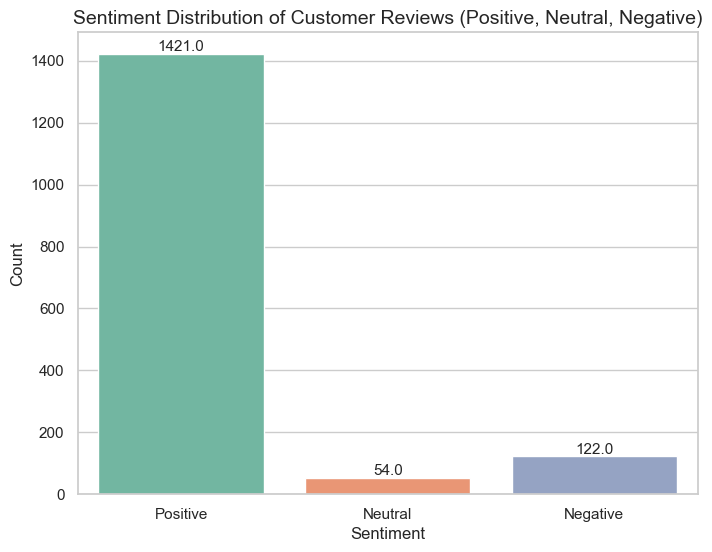

In [13]:
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=df, x='sentiment', palette='Set2')

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()


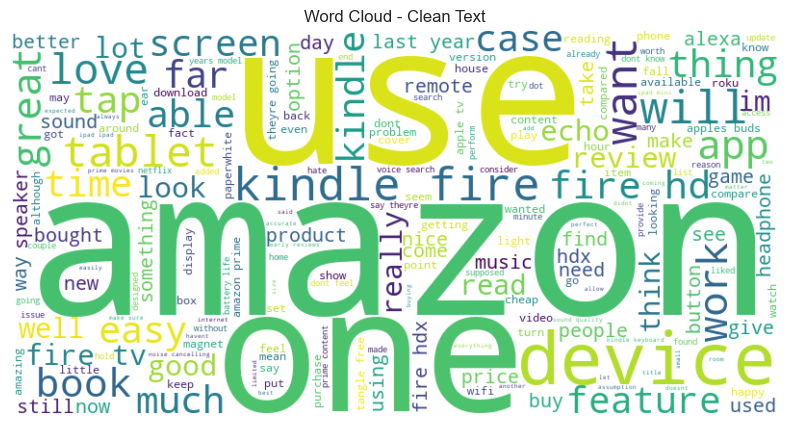

In [14]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white').generate(' '.join(df['Cleaned_Review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Clean Text")
plt.show()


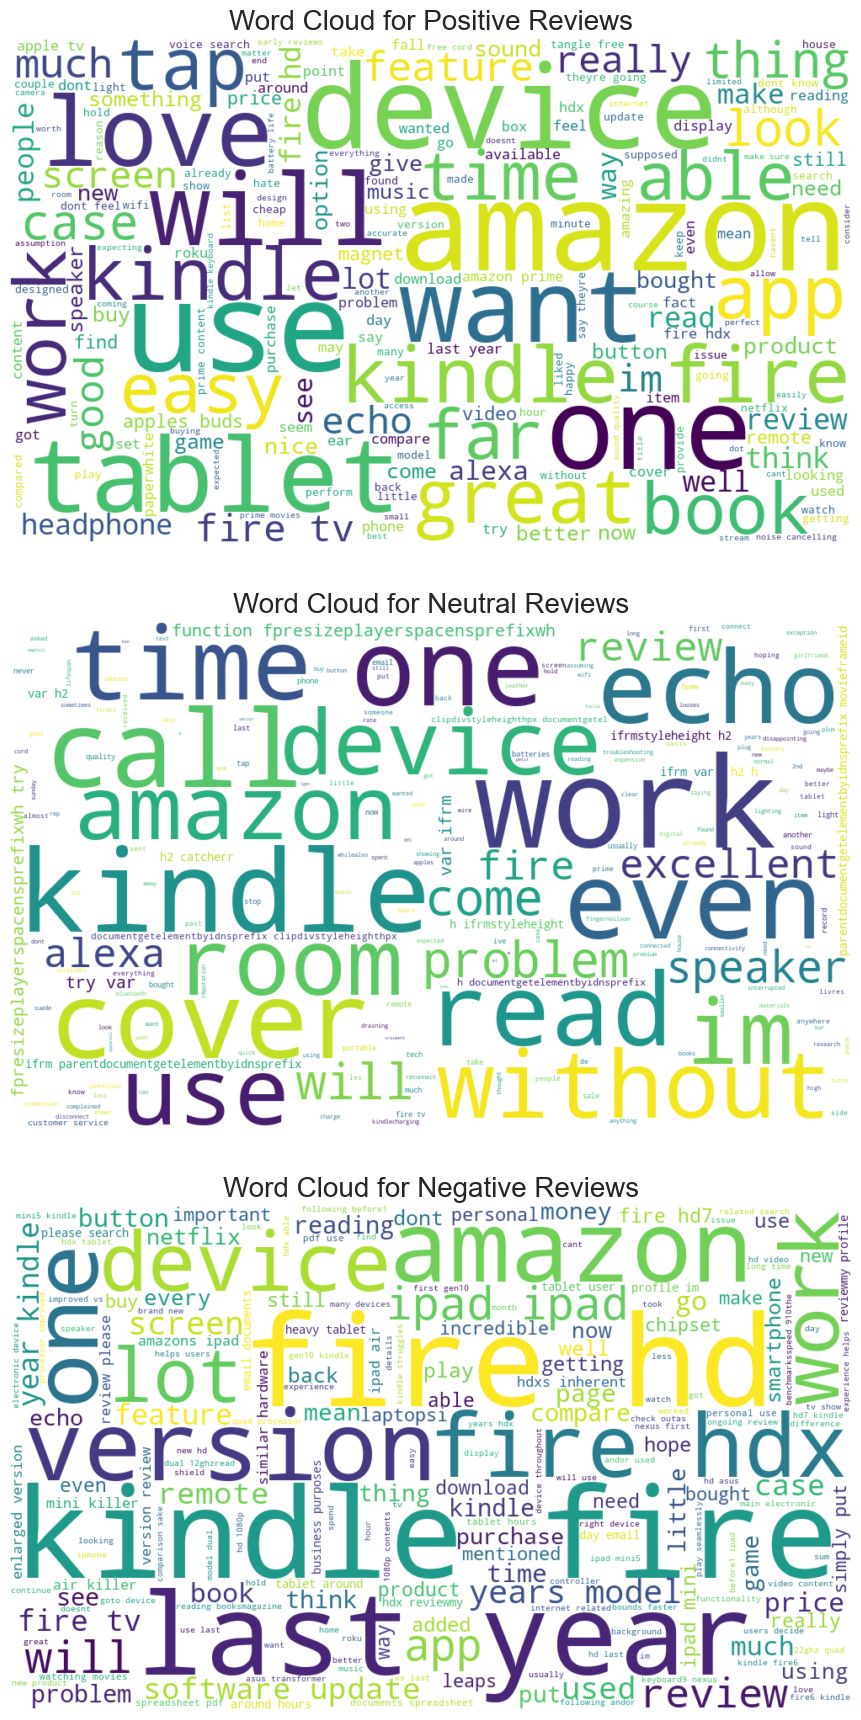

In [15]:
# Separate reviews based on sentiment
positive_reviews = " ".join(df[df['sentiment'] == 'Positive']['Cleaned_Review'].tolist())
neutral_reviews = " ".join(df[df['sentiment'] == 'Neutral']['Cleaned_Review'].tolist())
negative_reviews = " ".join(df[df['sentiment'] == 'Negative']['Cleaned_Review'].tolist())

# Generate word clouds with larger dimensions and font size
wordcloud_positive = WordCloud(width=1000, height=600, background_color='white', max_font_size=150).generate(positive_reviews)
wordcloud_neutral = WordCloud(width=1000, height=600, background_color='white', max_font_size=150).generate(neutral_reviews)
wordcloud_negative = WordCloud(width=1000, height=600, background_color='white', max_font_size=150).generate(negative_reviews)

# Plot the word clouds for each sentiment with larger figure size
plt.figure(figsize=(10, 18))

# Positive word cloud
plt.subplot(3, 1, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud for Positive Reviews', fontsize=20)
plt.axis('off')

# Neutral word cloud
plt.subplot(3, 1, 2)
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Word Cloud for Neutral Reviews', fontsize=20)
plt.axis('off')

# Negative word cloud
plt.subplot(3, 1, 3)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud for Negative Reviews', fontsize=20)
plt.axis('off')

# Show the word clouds
plt.tight_layout(pad=3)
plt.show()

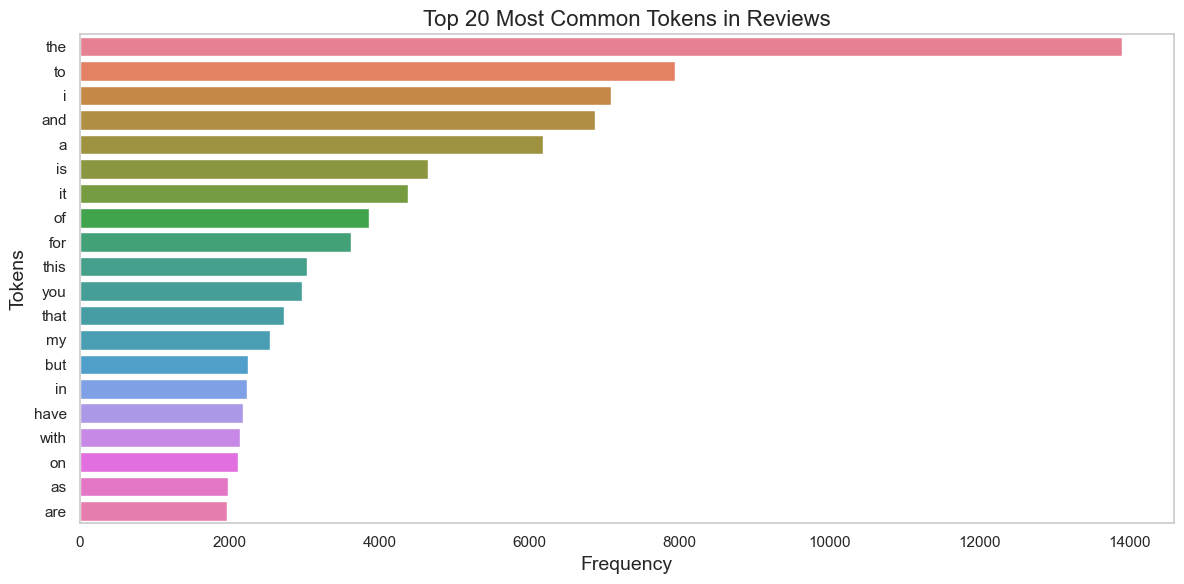

In [16]:
from collections import Counter

# Combine all tokens into a single list
all_tokens = [token for tokens in df['Tokenized_Review'] for token in tokens]

# Count the frequency of tokens
token_counts = Counter(all_tokens)

# Get the top 20 most common tokens
common_tokens = token_counts.most_common(20)  # Limiting to top 20

# Separate tokens and their frequencies
tokens, frequencies = zip(*common_tokens)

# Create a bar plot for the most frequent tokens
plt.figure(figsize=(12, 6))
sns.barplot(x=list(frequencies), y=list(tokens), palette='husl')  # Changed palette

# Improved title and axis labels
plt.title('Top 20 Most Common Tokens in Reviews', fontsize=16)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Tokens', fontsize=14)

# Add gridlines for easier reading of bar heights
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()  # Ensure layout is clean and labels fit well
plt.grid(False)
plt.show()


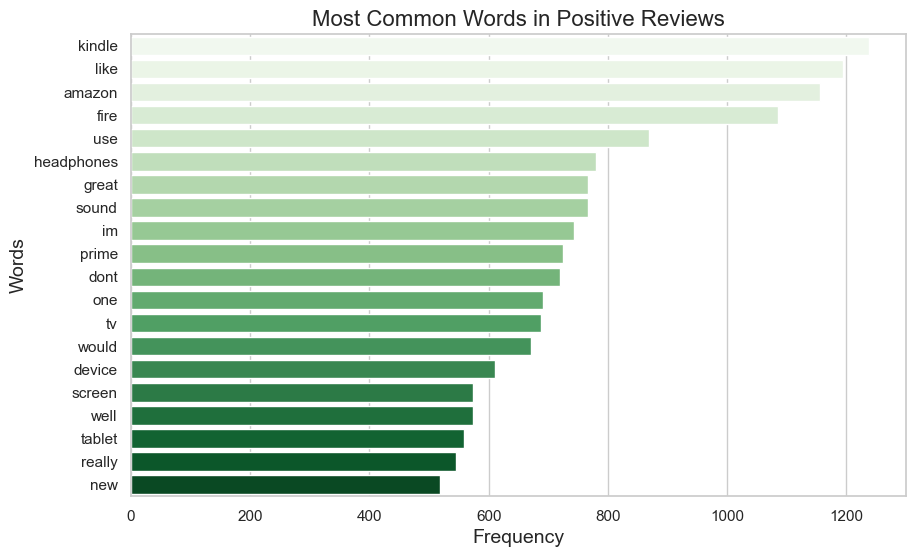

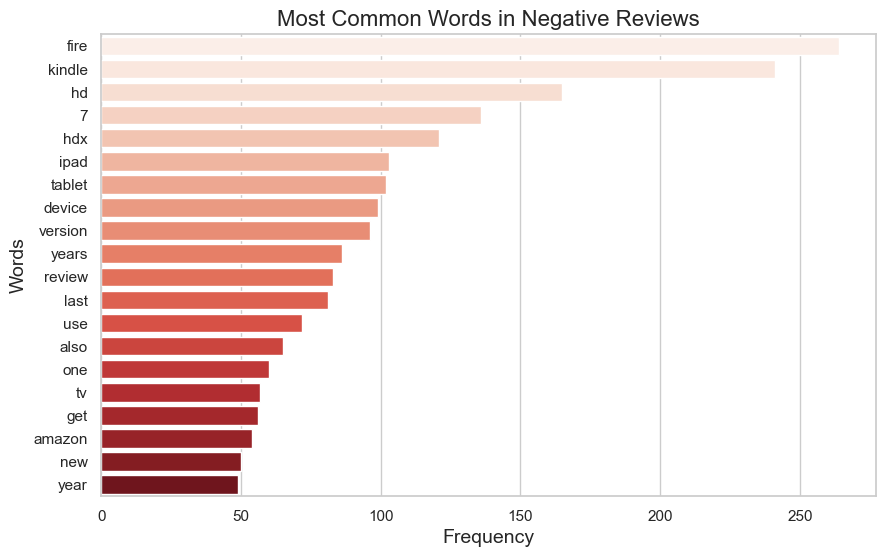

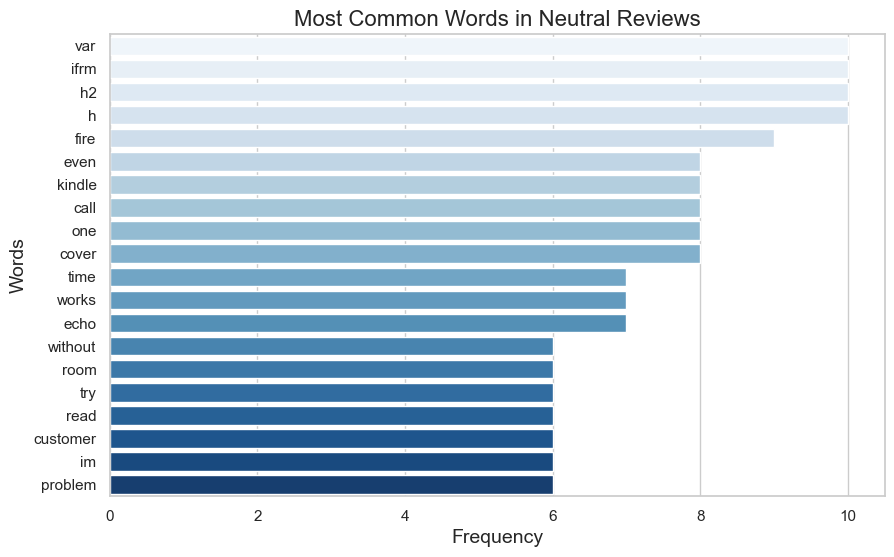

In [17]:
from collections import Counter

# Function to plot the most common words for each sentiment
def plot_most_common_words(common_words, sentiment, color):
    # Unzip the common_words tuple into two lists: words and their respective counts
    words, counts = zip(*common_words)
    
    # Create a bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), palette=color)
    
    # Set the title and axis labels
    plt.title(f'Most Common Words in {sentiment} Reviews', fontsize=16)
    plt.xlabel('Frequency', fontsize=14)
    plt.ylabel('Words', fontsize=14)
    
    # Display the chart
    plt.show()

# Generate the most common words for each sentiment

# Filter reviews based on sentiment
positive_reviews = df[df['sentiment'] == 'Positive']['No_Stopwords_Review']
negative_reviews = df[df['sentiment'] == 'Negative']['No_Stopwords_Review']
neutral_reviews = df[df['sentiment'] == 'Neutral']['No_Stopwords_Review']

# Combine all words into a single list for each sentiment
positive_words_list = [word for review in positive_reviews for word in review]
negative_words_list = [word for review in negative_reviews for word in review]
neutral_words_list = [word for review in neutral_reviews for word in review]

# Count the most common words in each sentiment's word list
positive_words = Counter(positive_words_list).most_common(20)
negative_words = Counter(negative_words_list).most_common(20)
neutral_words = Counter(neutral_words_list).most_common(20)

# Plot the most common words for Positive sentiment
plot_most_common_words(positive_words, 'Positive', 'Greens')

# Plot the most common words for Negative sentiment
plot_most_common_words(negative_words, 'Negative', 'Reds')

# Plot the most common words for Neutral sentiment
plot_most_common_words(neutral_words, 'Neutral', 'Blues')

In [18]:
# Deleting unwanted columns
df = df.drop(columns=['id', 'asins', 'brand', 'categories', 'dateAdded', 'dateUpdated', 'keys', 'name', 'prices', 'vader_scores', 'reviews.sourceURLs'])

# Displaying the first few rows of the dataframe to verify
df.head()

,reviews.text,Cleaned_Review,Tokenized_Review,Stemmed_Review,No_Stopwords_Review,compound,sentiment
0,I initially had trouble deciding between the p...,i initially had trouble deciding between the p...,"[i, initially, had, trouble, deciding, between...","[i, initi, had, troubl, decid, between, the, p...","[initially, trouble, deciding, paperwhite, voy...",0.9879,Positive
1,Allow me to preface this with a little history...,allow me to preface this with a little history...,"[allow, me, to, preface, this, with, a, little...","[allow, me, to, prefac, thi, with, a, littl, h...","[allow, preface, little, history, casual, read...",0.9881,Positive
2,I am enjoying it so far. Great for reading. Ha...,i am enjoying it so far great for reading had ...,"[i, am, enjoying, it, so, far, great, for, rea...","[i, am, enjoy, it, so, far, great, for, read, ...","[enjoying, far, great, reading, original, fire...",0.4364,Positive
3,I bought one of the first Paperwhites and have...,i bought one of the first paperwhites and have...,"[i, bought, one, of, the, first, paperwhites, ...","[i, bought, one, of, the, first, paperwhit, an...","[bought, one, first, paperwhites, pleased, con...",0.9746,Positive
4,I have to say upfront - I don't like coroporat...,i have to say upfront i dont like coroporate ...,"[i, have, to, say, upfront, i, dont, like, cor...","[i, have, to, say, upfront, i, dont, like, cor...","[say, upfront, dont, like, coroporate, hermeti...",0.9980,Positive


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Convert text data into numerical features using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limiting to top 5000 features

# Training and testing division
X = tfidf_vectorizer.fit_transform(df['Cleaned_Review'])
y = df['sentiment']

tfidf_vectorizer

TfidfVectorizer(max_features=5000)

In [20]:
# Visualizing data x
X.shape

(1597, 5000)

In [21]:
# Viewing y data
y.shape

(1597,)

In [22]:
# Import the LabelEncoder class from sklearn, which is used to convert categorical labels to numeric values
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder instance
le = LabelEncoder()

# Apply LabelEncoder to the target variable 'y', which contains categorical sentiment labels
# The fit_transform() method encodes the labels (e.g., 'Positive', 'Neutral', 'Negative') into numeric values (e.g., 0, 1, 2)
y = le.fit_transform(y)

# The 'le' object now contains the mapping between the original labels and the numeric values
le

LabelEncoder()

In [23]:
# Importing library
from sklearn.model_selection import train_test_split

# Training and testing division
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Viewing training data
print("Viewing rows and columns given by X train", X_train.shape)

# Viewing test data
print("Viewing rows and columns given y train", y_train.shape)

Viewing rows and columns given by X train (1277, 5000)
Viewing rows and columns given y train (1277,)


In [24]:
# Convert your TF-IDF sparse matrix to a dense matrix
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

In [25]:
# Importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Models to be evaluated
models = [ 
            # Naive Bayes Model (requires dense matrix)
            GaussianNB(),
    
            # Decision Tree Model
            DecisionTreeClassifier(random_state=42),
    
            # Random forest model
            RandomForestClassifier(n_estimators=100, random_state=42),
    
            # Logistic regression model
            LogisticRegression(random_state=50),
    
            # Ada Boost Model
            AdaBoostClassifier(random_state=45),
    
            # XGBoost Model (can use sparse matrix)
            XGBClassifier(tree_method='hist', random_state=42),
    
            # LightGBM Model (can use sparse matrix)
            LGBMClassifier(num_leaves=31,
                           boosting_type='gbdt',
                           bagging_fraction=0.9,
                           learning_rate=0.05,
                           feature_fraction=0.9,
                           bagging_freq=50,
                           verbose=50,),
    
            # K-Nearest Neighbors Model
            KNeighborsClassifier(n_neighbors=13), 
    
            # Gradient Boosting Classifier
            GradientBoostingClassifier(random_state=42)]

# Evaluate each model
for i, model in enumerate(models):
    # For GaussianNB (requires dense matrix)
    if isinstance(model, GaussianNB):
        model.fit(X_train_dense, y_train)
        train_accuracy = accuracy_score(y_train, model.predict(X_train_dense))
        test_accuracy = accuracy_score(y_test, model.predict(X_test_dense))
    else:
        # For all other models
        model.fit(X_train, y_train)
        train_accuracy = accuracy_score(y_train, model.predict(X_train))
        test_accuracy = accuracy_score(y_test, model.predict(X_test))

    print(f"Model {i+1}: {type(model).__name__}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    print("-----------------")

Model 1: GaussianNB
Training Accuracy: 0.9671
Testing Accuracy: 0.8844
-----------------
Model 2: DecisionTreeClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.8844
-----------------
Model 3: RandomForestClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.9187
-----------------
Model 4: LogisticRegression
Training Accuracy: 0.9178
Testing Accuracy: 0.9062
-----------------
Model 5: AdaBoostClassifier
Training Accuracy: 0.8888
Testing Accuracy: 0.8625
-----------------
Model 6: XGBClassifier
Training Accuracy: 0.9992
Testing Accuracy: 0.9250
-----------------
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ignored. Current value: bagging_freq=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ig

  File "/opt/homebrew/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py", line 270, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "/opt/homebrew/anaconda3/lib/python3.11/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/anaconda3/lib/python3.11/subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "/opt/homebrew/anaconda3/lib/python3.11/subprocess.py", line 1950, in _execute_child
    raise child_exception_type(errno_num, err_msg, err_filename)


[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 24
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 22
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 23
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM]

Model 9: GradientBoostingClassifier
Training Accuracy: 0.9992
Testing Accuracy: 0.9281
-----------------


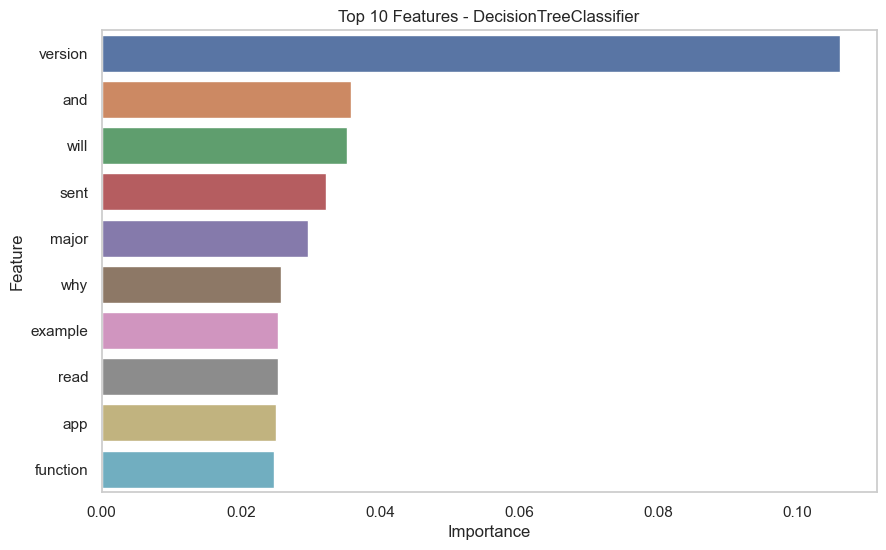

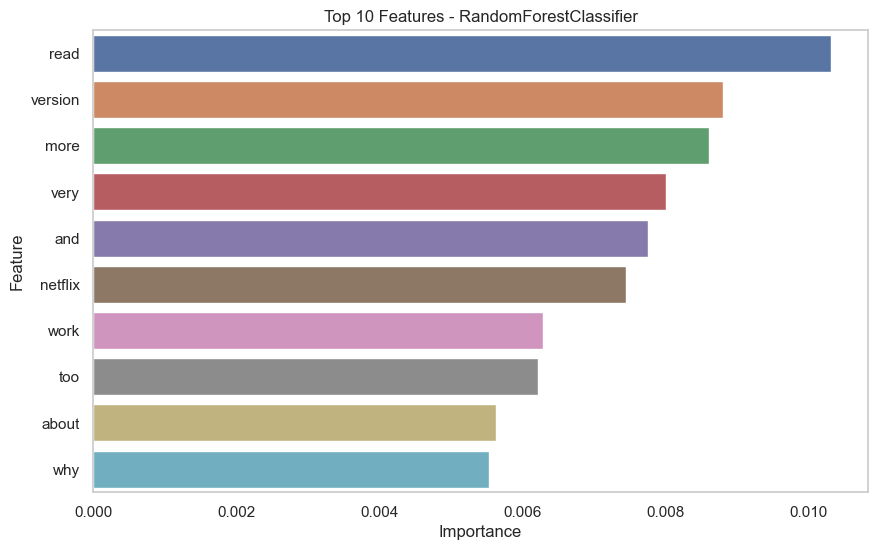

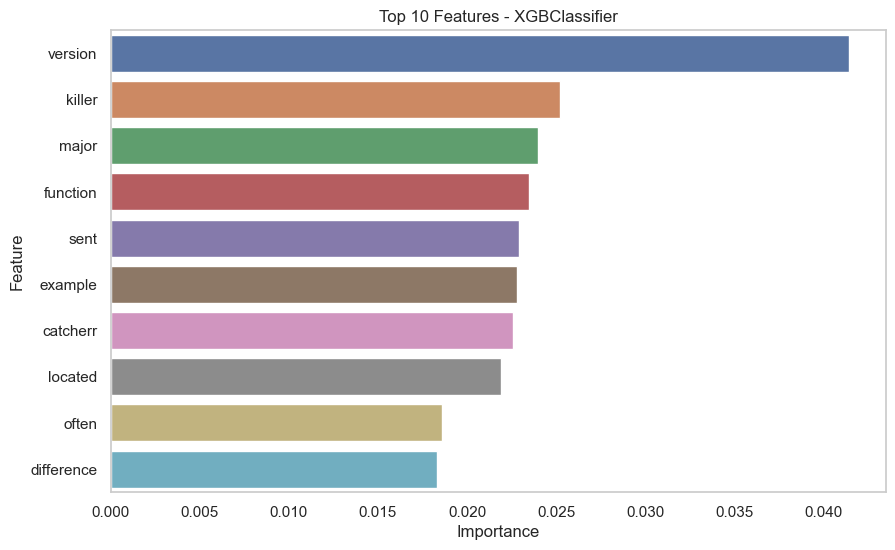

[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.942166
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.931958
[LightGBM] [Debug] init for col-wise cost 0.082552 seconds, init for row-wise cost 0.021545 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 19993
[LightGBM] [Info] Number of data points in the train set: 1277, number of used features: 1120
[LightGBM] [Info] Start training from score -2.641409
[LightGBM] [Info] Start training from score -3.323627
[LightGBM] [Info] Start training from score -0.113485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 17 and depth = 13
[LightGBM] [Warning] No further splits 

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 23
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM]

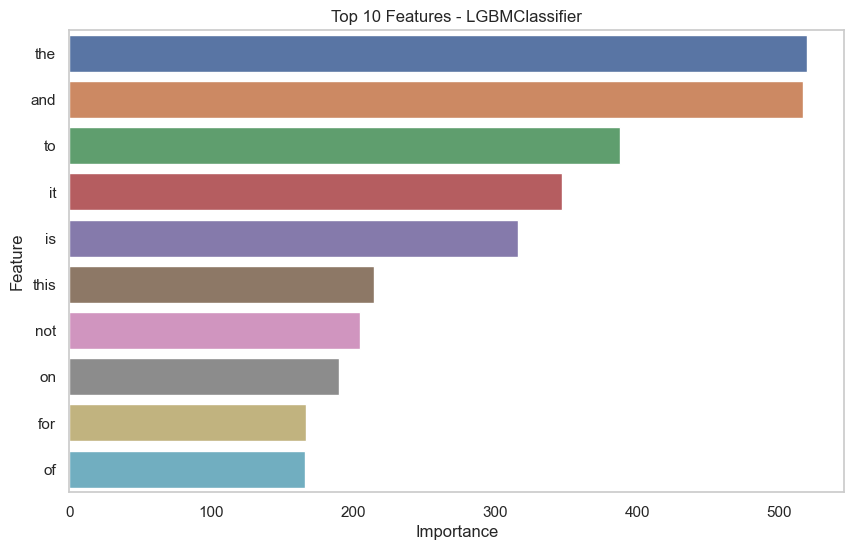

In [26]:
# Train models that support feature importances
models_with_feature_importances = [("DecisionTreeClassifier", DecisionTreeClassifier(random_state=42)),
                                   ("RandomForestClassifier", RandomForestClassifier(n_estimators=100, random_state=42)),
                                   ("XGBClassifier", XGBClassifier(random_state=42)),
                                   ("LGBMClassifier", LGBMClassifier(random_state=42))]

# Get feature names from the TfidfVectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Iterate over models
for model_name, model in models_with_feature_importances:
    
    # Train model
    model.fit(X_train, y_train)
    
    # Get importance of features
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    else:
        # If the model does not have feature_importances_, continue to the next model
        print(f"{model_name} does not support feature importances.")
        continue

    # Create DataFrame for easier viewing
    feature_importances_df = pd.DataFrame({'Feature': feature_names, 
                                           'Importance': feature_importances})
    
    # Sort by importance
    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances_df[:10])
    plt.title(f"Top 10 Features - {model_name}")
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(False)
    plt.show()

Model 1: GaussianNB
Training Accuracy: 0.9671104150352389
Testing Accuracy: 0.884375

Confusion matrix for Model 1: GaussianNB 

 [[ 12   0  19]
 [  0   2   6]
 [ 11   1 269]]


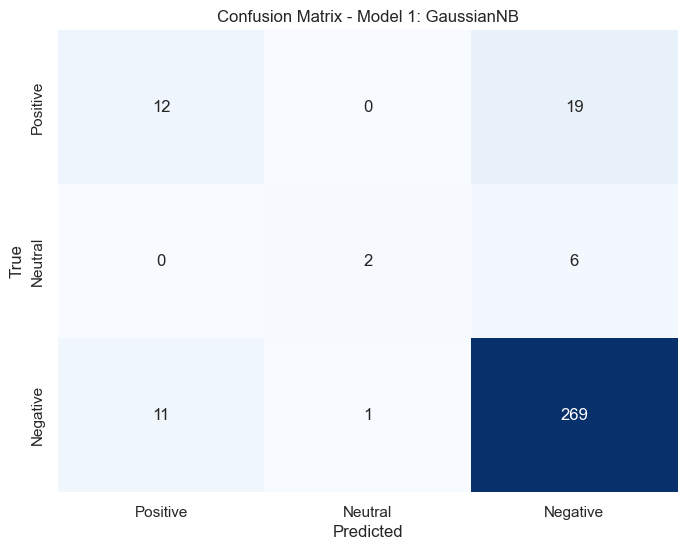

------------------
Model 2: DecisionTreeClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.884375

Confusion matrix for Model 2: DecisionTreeClassifier 

 [[ 14   1  16]
 [  1   3   4]
 [  5  10 266]]


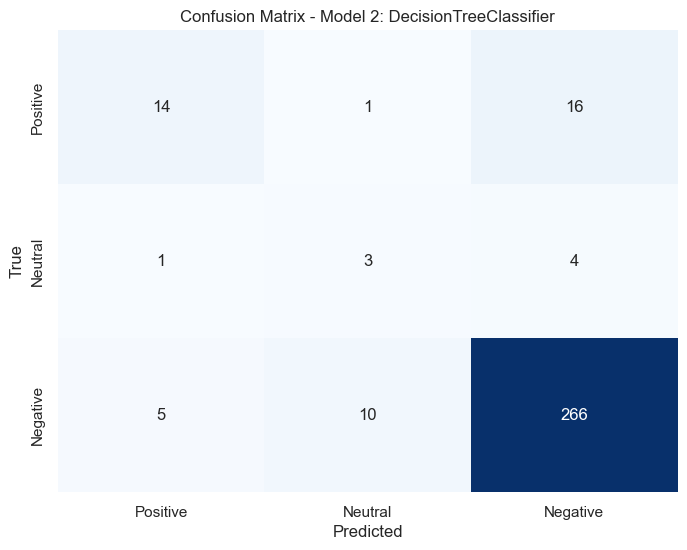

------------------
Model 3: RandomForestClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.91875

Confusion matrix for Model 3: RandomForestClassifier 

 [[ 11   0  20]
 [  0   2   6]
 [  0   0 281]]


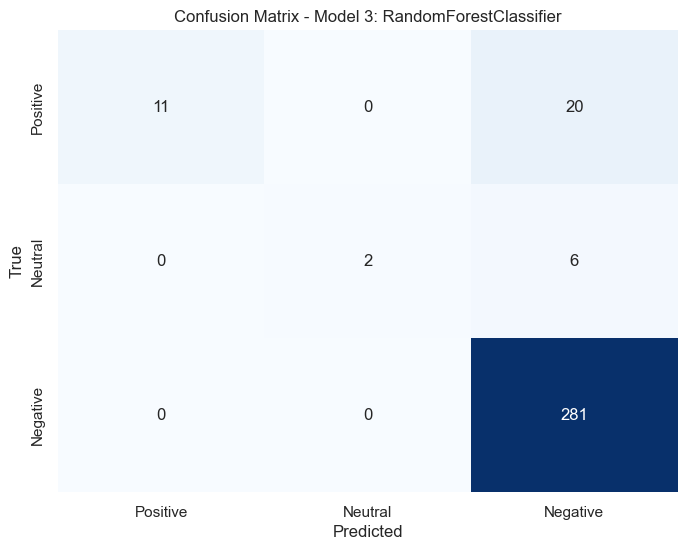

------------------
Model 4: LogisticRegression
Training Accuracy: 0.9177760375880971
Testing Accuracy: 0.90625

Confusion matrix for Model 4: LogisticRegression 

 [[  7   0  24]
 [  0   2   6]
 [  0   0 281]]


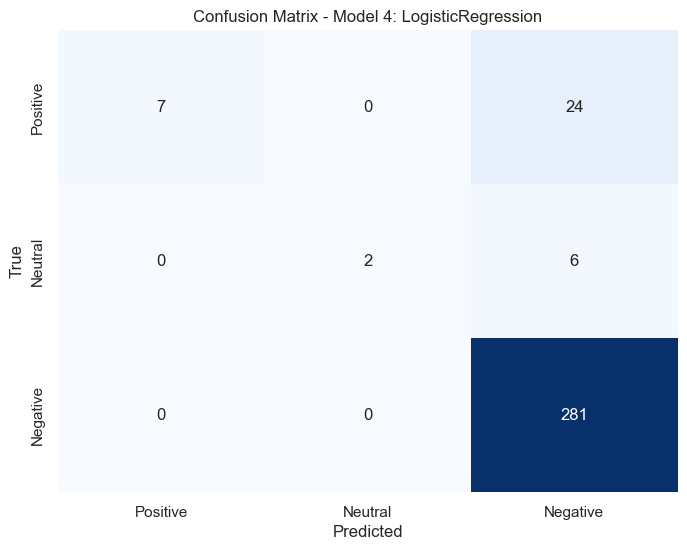

------------------
Model 5: AdaBoostClassifier
Training Accuracy: 0.8888018794048551
Testing Accuracy: 0.8625

Confusion matrix for Model 5: AdaBoostClassifier 

 [[  2   1  28]
 [  0   4   4]
 [ 10   1 270]]


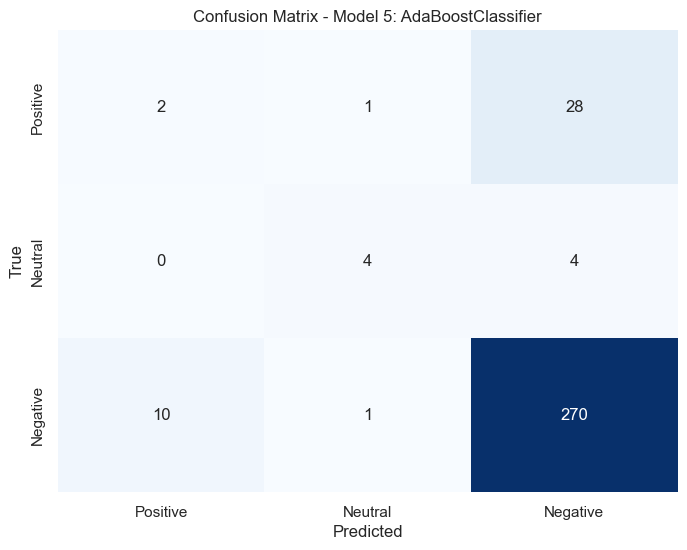

------------------
Model 6: XGBClassifier
Training Accuracy: 0.9992169146436961
Testing Accuracy: 0.925

Confusion matrix for Model 6: XGBClassifier 

 [[ 15   0  16]
 [  0   2   6]
 [  1   1 279]]


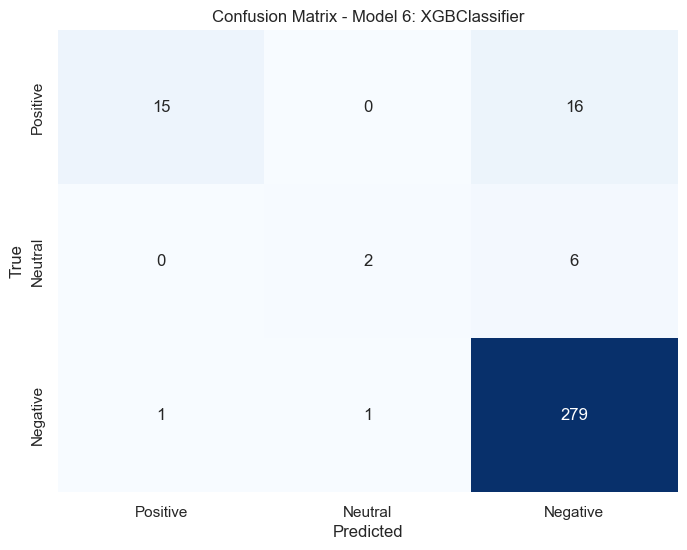

------------------
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ignored. Current value: bagging_freq=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ignored. Current value: bagging_freq=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.942166
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.931958
[LightGBM] [Debug] init for col-wise cost 0.047634 seconds, init for row-wise cost 0.051263 seconds
[LightGBM] [Info] Auto

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 23
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM]

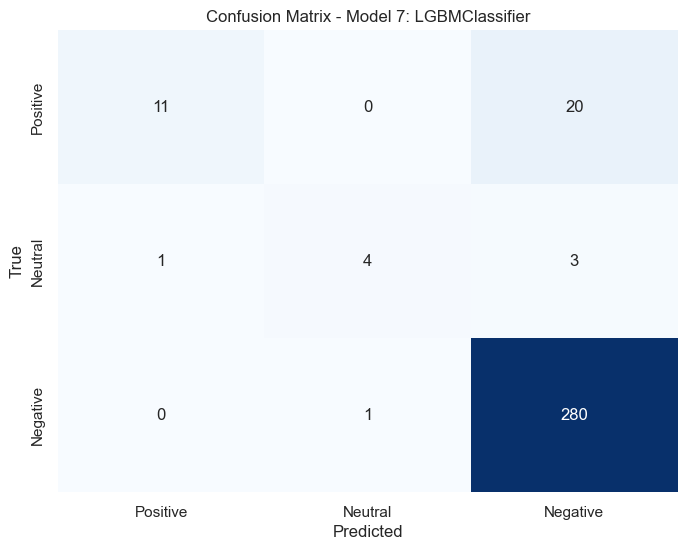

------------------
Model 8: KNeighborsClassifier
Training Accuracy: 0.9075959279561472
Testing Accuracy: 0.89375

Confusion matrix for Model 8: KNeighborsClassifier 

 [[  6   0  25]
 [  1   1   6]
 [  2   0 279]]


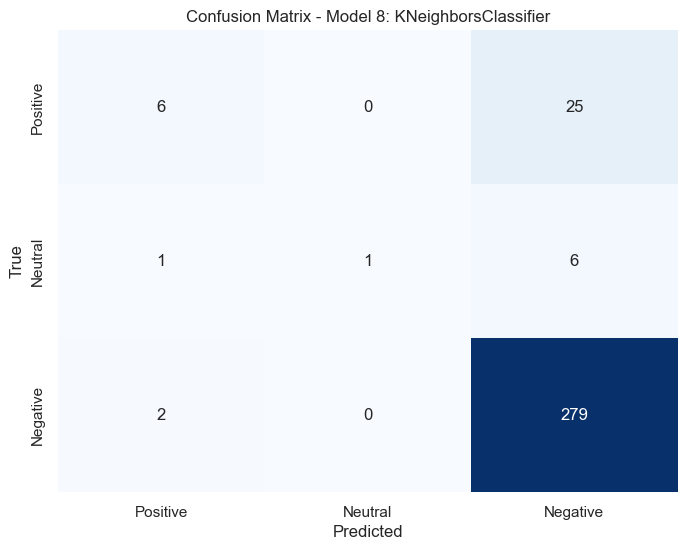

------------------
Model 9: GradientBoostingClassifier
Training Accuracy: 0.9992169146436961
Testing Accuracy: 0.928125

Confusion matrix for Model 9: GradientBoostingClassifier 

 [[ 14   0  17]
 [  0   2   6]
 [  0   0 281]]


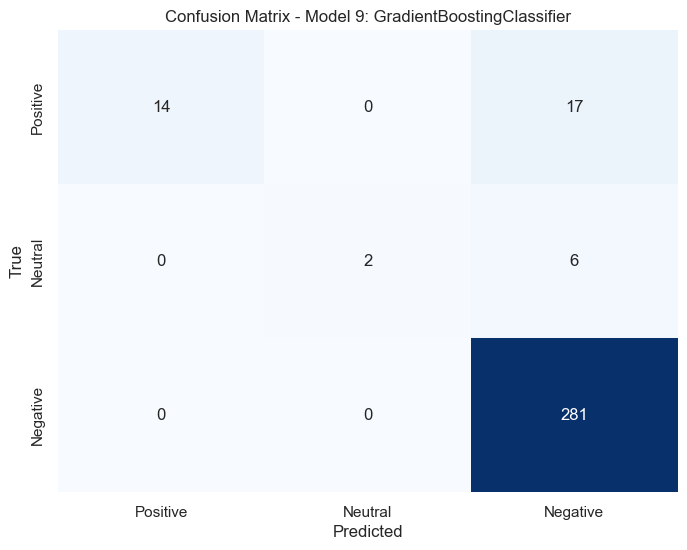

------------------


In [27]:
from sklearn.metrics import confusion_matrix,classification_report

# Define your sentiment labels
labels = ['Positive', 
          'Neutral', 
          'Negative']

# Convert your TF-IDF sparse matrix to a dense matrix for models that require dense input
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Evaluate each model
for i, model in enumerate(models):
    # Check if the model requires dense data (like GaussianNB)
    if isinstance(model, GaussianNB):
        model.fit(X_train_dense, y_train)
        y_train_pred = model.predict(X_train_dense)
        y_test_pred = model.predict(X_test_dense)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"Model {i+1}: {type(model).__name__}")
    print(f"Training Accuracy: {train_accuracy}")
    print(f"Testing Accuracy: {test_accuracy}")
    print()

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    print(f'Confusion matrix for Model {i+1}: {type(model).__name__} \n\n', cm)
    
    # Plot the confusion matrix with annotations for three classes
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels)
    
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Model {i+1}: {type(model).__name__}")
    plt.show()
    
    print("------------------")

Model 1: GaussianNB
Training Accuracy: 0.9671
Testing Accuracy: 0.8844


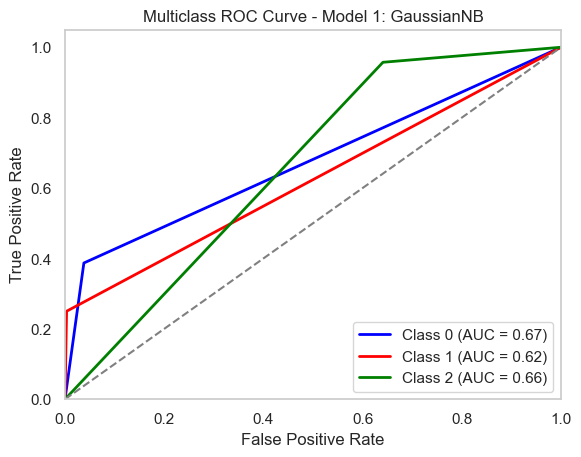

------------------
Model 2: DecisionTreeClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.8844


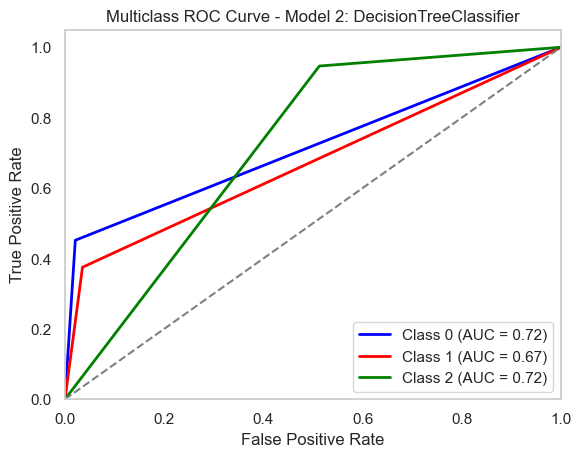

------------------
Model 3: KNeighborsClassifier
Training Accuracy: 0.9381
Testing Accuracy: 0.9031


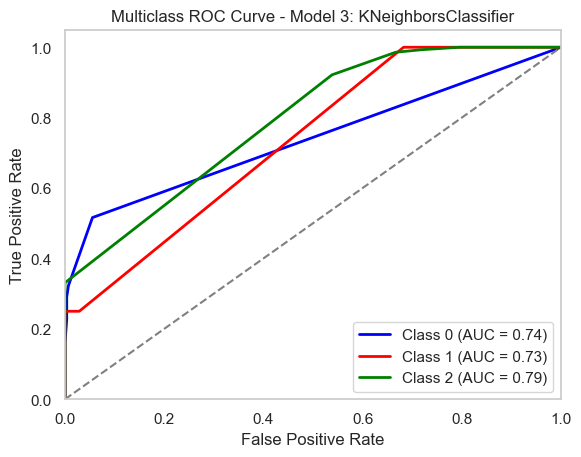

------------------
Model 4: RandomForestClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.9187


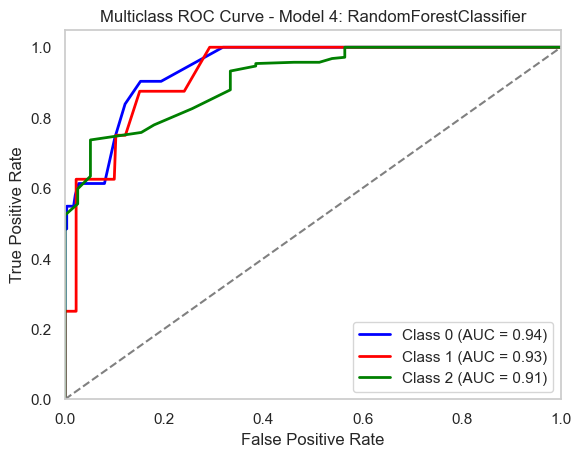

------------------
Model 5: LogisticRegression
Training Accuracy: 0.9178
Testing Accuracy: 0.9062


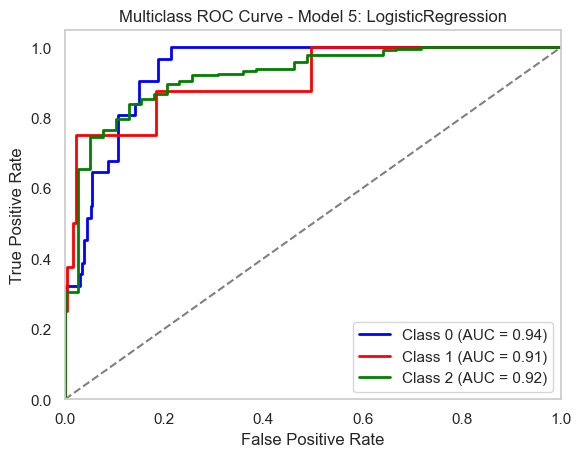

------------------
Model 6: AdaBoostClassifier
Training Accuracy: 0.8888
Testing Accuracy: 0.8625


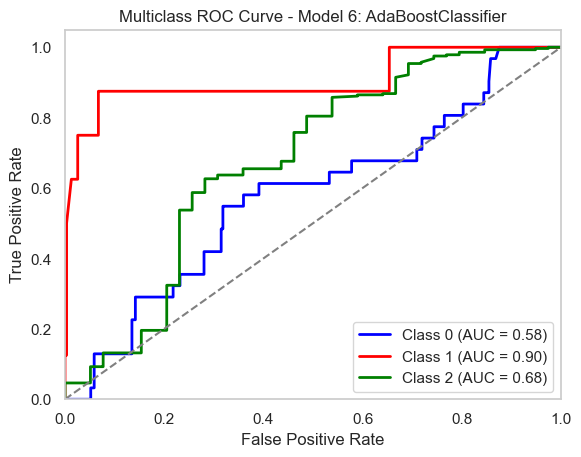

------------------
Model 7: GradientBoostingClassifier
Training Accuracy: 0.9992
Testing Accuracy: 0.9281


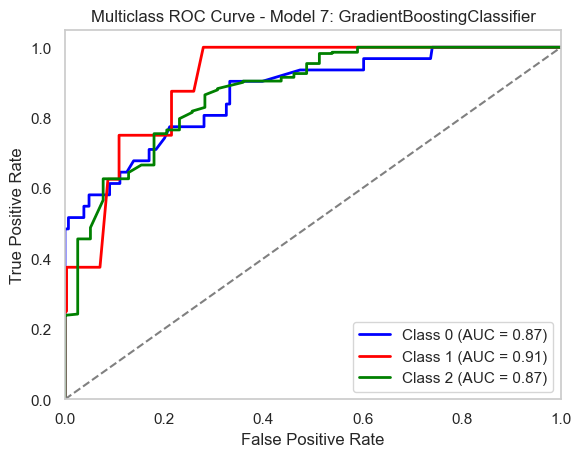

------------------
Model 8: XGBClassifier
Training Accuracy: 0.9992
Testing Accuracy: 0.9250


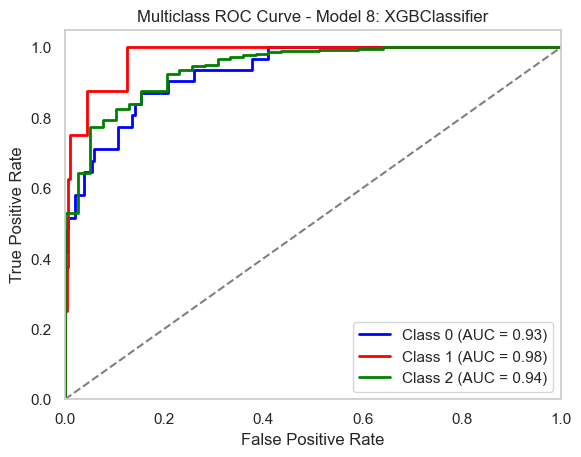

------------------
Model 9: LGBMClassifier
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.942166
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.931958
[LightGBM] [Debug] init for col-wise cost 0.217626 seconds, init for row-wise cost 0.119804 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.218659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 19993
[LightGBM] [Info] Number of data points in the train set: 1277, number of used features: 1120
[LightGBM] [Info] Start training from score -2.641409
[LightGBM] [Info] Start training from score -3.323627
[LightGBM] [Info] Start training from score -0.113485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 17 and depth =

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 23
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 24
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 22
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM]

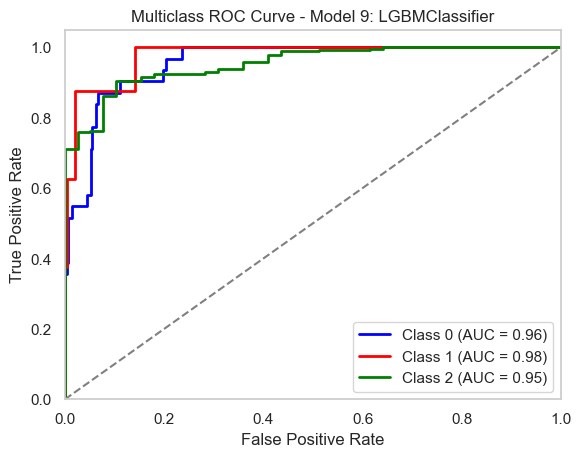

------------------
Model 10: CatBoostClassifier
Training Accuracy: 0.9992
Testing Accuracy: 0.9281


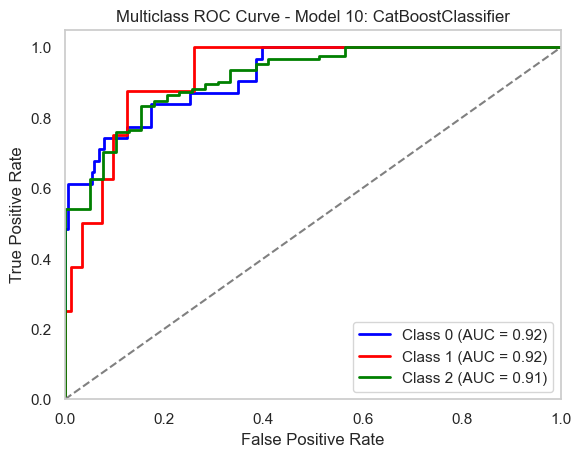

------------------


In [28]:
# Importing necessary libraries
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert sparse matrix to dense for models that require dense input
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Binarize the output labels for multiclass ROC-AUC
n_classes = len(np.unique(y_train))

# Adjust this depending on the number of classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  

# Models to be evaluated
models = [
    GaussianNB(),
    DecisionTreeClassifier(random_state=42),
    KNeighborsClassifier(),
    RandomForestClassifier(n_estimators=100, random_state=42),
    LogisticRegression(random_state=42, max_iter=1000),
    AdaBoostClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42),
    XGBClassifier(random_state=42),
    LGBMClassifier(),
    CatBoostClassifier(task_type='CPU', iterations=1000, learning_rate=0.1, depth=6, verbose=0, random_state=42)
]

# Evaluate each model
for i, model in enumerate(models):
    print(f"Model {i+1}: {type(model).__name__}")
    
    # Check if the model requires dense data (like GaussianNB)
    if isinstance(model, (GaussianNB, KNeighborsClassifier)):
        model.fit(X_train_dense, y_train)
        y_train_pred = model.predict(X_train_dense)
        y_test_pred = model.predict(X_test_dense)
        y_probs = model.predict_proba(X_test_dense)
    else:
        # For all other models, use sparse matrices
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)
        else:
            print(f"{type(model).__name__} does not support predict_proba, skipping AUC/ROC plot.")
            continue
    
    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    
    # Calculate ROC curve and AUC for each class (multiclass)
    if 'y_probs' in locals():
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for j in range(n_classes):
            fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_probs[:, j])
            roc_auc[j] = roc_auc_score(y_test_bin[:, j], y_probs[:, j])
        
        # Plot ROC curve for each class
        plt.figure()
        colors = ['blue', 'red', 'green']
        for j, color in enumerate(colors):
            plt.plot(fpr[j], tpr[j], color=color, lw=2, label=f'Class {j} (AUC = {roc_auc[j]:.2f})')
        
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Multiclass ROC Curve - Model {i+1}: {type(model).__name__}')
        plt.legend(loc="lower right")
        plt.grid(False)
        plt.show()
    
    print("------------------")

In [29]:
# Define sentiment labels (assuming 3-class classification)
sentiment_labels = ['Positive', 'Neutral', 'Negative']

# Convert sparse matrix to dense for models that require dense input
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Models to be evaluated
models = [
          GaussianNB(),
          DecisionTreeClassifier(random_state=42),
          KNeighborsClassifier(),
          RandomForestClassifier(n_estimators=100, random_state=42),
          LogisticRegression(random_state=42, max_iter=1000),
          AdaBoostClassifier(random_state=42),
          XGBClassifier(random_state=42),
          LGBMClassifier(),
          CatBoostClassifier(task_type='CPU', iterations=1000, learning_rate=0.1, depth=6, verbose=0, random_state=42)]

# Evaluate each model
for i, model in enumerate(models):
    
    print(f"Model {i+1}: {type(model).__name__}")
    
    # For models that require dense matrices
    if isinstance(model, (GaussianNB, KNeighborsClassifier)):
        model.fit(X_train_dense, y_train)
        y_train_pred = model.predict(X_train_dense)
        y_test_pred = model.predict(X_test_dense)
    else:
        # For models that work with sparse matrices
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"Training Accuracy: {train_accuracy}")
    print(f"Testing Accuracy: {test_accuracy}")

    # Generate classification report with sentiment labels
    report = classification_report(y_test, y_test_pred, target_names=sentiment_labels)
    print()
    print("Classification Report:")
    print(report)
    print("=======================================")


Model 1: GaussianNB
Training Accuracy: 0.9671104150352389
Testing Accuracy: 0.884375

Classification Report:
              precision    recall  f1-score   support

    Positive       0.52      0.39      0.44        31
     Neutral       0.67      0.25      0.36         8
    Negative       0.91      0.96      0.94       281

    accuracy                           0.88       320
   macro avg       0.70      0.53      0.58       320
weighted avg       0.87      0.88      0.87       320

Model 2: DecisionTreeClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.884375

Classification Report:
              precision    recall  f1-score   support

    Positive       0.70      0.45      0.55        31
     Neutral       0.21      0.38      0.27         8
    Negative       0.93      0.95      0.94       281

    accuracy                           0.88       320
   macro avg       0.61      0.59      0.59       320
weighted avg       0.89      0.88      0.88       320

Model 3: KNeighborsClas

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 25
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 24
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM]

In [30]:
# Convert sparse matrix to dense for models that require dense input
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Models to be evaluated
models = [GaussianNB(),
          DecisionTreeClassifier(random_state=42),
          KNeighborsClassifier(),
          RandomForestClassifier(n_estimators=100, random_state=42),
          LogisticRegression(random_state=42, max_iter=1000),
          AdaBoostClassifier(random_state=42),
          XGBClassifier(random_state=42),
          GradientBoostingClassifier(random_state=42),
          LGBMClassifier()]

# List to store metrics for each model
metricas = []

# Evaluate each model
for model in models:
    print(f"Evaluating {type(model).__name__}")
    
    # For models that require dense matrices
    if isinstance(model, (GaussianNB, KNeighborsClassifier)):
        model.fit(X_train_dense, y_train)
        train_accuracy = accuracy_score(y_train, model.predict(X_train_dense))
        test_accuracy = accuracy_score(y_test, model.predict(X_test_dense))
        report = classification_report(y_test, model.predict(X_test_dense), output_dict=True)
    else:
        # For models that work with sparse matrices
        model.fit(X_train, y_train)
        train_accuracy = accuracy_score(y_train, model.predict(X_train))
        test_accuracy = accuracy_score(y_test, model.predict(X_test))
        report = classification_report(y_test, model.predict(X_test), output_dict=True)
    
    # Extract metrics of interest from the report
    metrics = {"Model": type(model).__name__,
               "Accuracy": test_accuracy,
               "Precision": report['weighted avg']['precision'],
               "Recall": report['weighted avg']['recall'],
               "F1-score": report['weighted avg']['f1-score'],
               "Support": report['weighted avg']['support']}
    metricas.append(metrics)

# Convert the list of dictionaries into a DataFrame
df_metricas = pd.DataFrame(metricas)

# Function to highlight the maximum value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# Apply the highlighting function
df_metricas_styled = df_metricas.style.apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1-score'])

# Display the styled DataFrame with metrics
df_metricas_styled

Evaluating GaussianNB
Evaluating DecisionTreeClassifier
Evaluating KNeighborsClassifier
Evaluating RandomForestClassifier
Evaluating LogisticRegression
Evaluating AdaBoostClassifier
Evaluating XGBClassifier
Evaluating GradientBoostingClassifier
Evaluating LGBMClassifier
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.942166
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.931958
[LightGBM] [Debug] init for col-wise cost 0.184829 seconds, init for row-wise cost 0.147051 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.190058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 19993
[LightGBM] [Info] Number of data points in the train set: 1277, number of used features: 1120
[LightGBM] [Info] Start training from score -2.641409
[LightGBM] [Info]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM]

,Model,Accuracy,Precision,Recall,F1-score,Support
0,GaussianNB,0.884375,0.870665,0.884375,0.873766,320.000000
1,DecisionTreeClassifier,0.884375,0.889887,0.884375,0.883924,320.000000
2,KNeighborsClassifier,0.903125,0.893504,0.903125,0.885766,320.000000
3,RandomForestClassifier,0.918750,0.925631,0.918750,0.900040,320.000000
4,LogisticRegression,0.906250,0.915293,0.906250,0.879316,320.000000
5,AdaBoostClassifier,0.862500,0.817891,0.862500,0.836655,320.000000
6,XGBClassifier,0.925000,0.921430,0.925000,0.912840,320.000000
7,GradientBoostingClassifier,0.928125,0.933563,0.928125,0.913878,320.000000
8,LGBMClassifier,0.928125,0.924179,0.928125,0.917429,320.000000


In [31]:
import pickle

# Saving each model to a .pkl file
for i, model in enumerate(models):
    
    # For GaussianNB (requires dense matrix)
    if isinstance(model, GaussianNB):
        model.fit(X_train_dense, y_train)  # Training the model on the dense matrix
        train_accuracy = accuracy_score(y_train, model.predict(X_train_dense))  # Computing accuracy on training data
        test_accuracy = accuracy_score(y_test, model.predict(X_test_dense))  # Computing accuracy on test data
    else:
        # For other models
        model.fit(X_train, y_train)  # Training the model on the original matrix
        train_accuracy = accuracy_score(y_train, model.predict(X_train))  # Computing accuracy on training data
        test_accuracy = accuracy_score(y_test, model.predict(X_test))  # Computing accuracy on test data

    # Displaying results
    print(f"Model {i+1}: {type(model).__name__}")  # Printing the type of model
    print("-----------------")

    # Saving the model as a .pkl file
    model_filename = f"model_{type(model).__name__}.pkl"  # Defining the filename for saving
    with open(model_filename, 'wb') as file:
        pickle.dump(model, file)  # Serializing the model object
        print(f"Model {type(model).__name__} saved as {model_filename}")  # Confirming that the model has been saved

Model 1: GaussianNB
-----------------
Model GaussianNB saved as model_GaussianNB.pkl
Model 2: DecisionTreeClassifier
-----------------
Model DecisionTreeClassifier saved as model_DecisionTreeClassifier.pkl
Model 3: KNeighborsClassifier
-----------------
Model KNeighborsClassifier saved as model_KNeighborsClassifier.pkl
Model 4: RandomForestClassifier
-----------------
Model RandomForestClassifier saved as model_RandomForestClassifier.pkl
Model 5: LogisticRegression
-----------------
Model LogisticRegression saved as model_LogisticRegression.pkl
Model 6: AdaBoostClassifier
-----------------
Model AdaBoostClassifier saved as model_AdaBoostClassifier.pkl
Model 7: XGBClassifier
-----------------
Model XGBClassifier saved as model_XGBClassifier.pkl
Model 8: GradientBoostingClassifier
-----------------
Model GradientBoostingClassifier saved as model_GradientBoostingClassifier.pkl
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.942166
[LightGBM] [Debug] Dataset::GetMu

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 20
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 23
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 24
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 22
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM]

Model LGBMClassifier saved as model_LGBMClassifier.pkl


In [32]:
%pip install spacy



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
# Importing libraries
import gensim
import spacy
from gensim import corpora
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [34]:
# Database
data.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,manufacturer,manufacturerNumber,name,prices,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-08-08T00:00:00.000Z,NaN,139.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-09-01T00:00:00.000Z,NaN,126.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-07-20T00:00:00.000Z,NaN,69.0,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2017-06-16T00:00:00.000Z,NaN,2.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2016-08-11T00:00:00.000Z,NaN,17.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [35]:
# Function for preprocessing and stopwords removal
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())  # Tokenizing and converting to lowercase
    tokens = [word for word in tokens if word.isalpha()]  # Removing non-alphabetic tokens
    tokens = [word for word in tokens if word not in stop_words]  # Removing stopwords
    return tokens

# Applying the preprocessing function
data['processed_text'] = data['reviews.text'].apply(preprocess)

# Creating the dictionary (mapping unique words to IDs)
dictionary = corpora.Dictionary(data['processed_text'])

# Creating the corpus (word frequency)
corpus = [dictionary.doc2bow(text) for text in data['processed_text']]

In [ ]:
# Function to Determine the Best Number of Topics (Coherence)

from gensim.models import CoherenceModel

def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=15)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

# Define the parameters
start = 2
limit = 20
step = 2

# Run the function
model_list, coherence_values = compute_coherence_values(dictionary, corpus, data['processed_text'], start, limit, step)

# Visually Show the Number of Topics
# Plot the coherence graph
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence")
plt.title("Topic Coherence")
plt.grid(False)
plt.show()

## List of Coherence Values
# Display coherence values to identify the inflection point
for m, cv in zip(range(start, limit, step), coherence_values):
    print(f"Num Topics = {m} Coherence Value = {round(cv, 4)}")
    

In [ ]:
# LDA model
# Choosing the optimal number of topics based on the graph
# Example, fit according to the graph
optimal_num_topics = 16

# Building the final LDA model
lda_model = gensim.models.LdaModel(corpus=corpus, num_topics=optimal_num_topics, id2word=dictionary, passes=15)

In [ ]:
## Compute Model Perplexity
# Compute perplexity
print(f"Perplexity: {lda_model.log_perplexity(corpus)}")

In [ ]:
## Compute Model Perplexity
# Compute perplexity
print(f"Perplexity: {lda_model.log_perplexity(corpus)}")
# Compute model coherence
coherence_model_lda = CoherenceModel(model=lda_model, texts=data['processed_text'], dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f"LDA Model Coherence: {coherence_lda}")

In [ ]:
%pip install pyLDAvis

In [ ]:
pip install --upgrade pandas bottleneck


In [ ]:
pip install --upgrade joblib pyLDAvis


In [ ]:
# Visualizing Topics in Clusters
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Preparing the visualization
lda_visualization = gensimvis.prepare(lda_model, corpus, dictionary)

# Displaying the visualization
pyLDAvis.display(lda_visualization)

In [ ]:
# Function to Determine the Main Topic in Each Text
# Function to find the main topic for each document
def dominant_topic(ldamodel, corpus):
    topics = []
    for row in ldamodel[corpus]:
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        topics.append(row[0][0])
    return topics

# Find the dominant topic
data['dominant_topic'] = dominant_topic(lda_model, corpus)

In [ ]:
# Count the number of documents (text) per topic
topic_counts = data['dominant_topic'].value_counts()
print(topic_counts)

In [ ]:
# Creating English Stopwords with Spacy

import spacy

# Load the English Spacy model
nlp = spacy.load('en_core_web_sm')

# Extract stopwords from Spacy
stop_words = nlp.Defaults.stop_words

def preprocess(text):
    tokens = word_tokenize(text.lower()) # Tokenize and convert text to lowercase
    tokens = [word for word in tokens if word.isalpha()] # Remove non-word tokens
    tokens = [word for word in tokens if word not in stop_words] # Remove English stopwords
    return tokens

# Applying preprocessing to the text column
data['processed_text'] = data['reviews.text'].apply(preprocess)

In [ ]:
# Viewing WordClouds for Each Topic

# Function to generate WordClouds for each topic
def plot_wordcloud(lda_model, topic_num):
    # Extract the words and their frequencies for the topic
    topic_terms = dict(lda_model.show_topic(topic_num, 10)) # 10 most frequent words
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_terms)
    
    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f'Topic {topic_num + 1}')
    plt.show()

# Generate WordClouds for all topics
for i in range(optimal_num_topics): plot_wordcloud(lda_model, i)

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
import re

# Downloading NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

In [ ]:
# Database
df = pd.read_csv("7817_1.csv")

# Assuming the texts are in the 'reviews.text' column
reviews = df['reviews.text'].values.tolist()

# Visualizing dataset
df.head()

In [ ]:
def preprocess_text(text):
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text.lower())
    # Remove stopwords
    tokens = [word for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

# Apply the preprocessing function to the 'reviews.text' column
df['cleaned_text'] = df['reviews.text'].apply(preprocess_text)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Text vectorization (Bag of Words)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(reviews)

In [ ]:
# Get the vocabulary (feature names) from the vectorizer
vocabulario = vectorizer.get_feature_names_out()

In [ ]:
# Function to compute coherence and perplexity values for different numbers of topics
def compute_coherence_values(corpus, vectorizer, start, limit, step):
    coherence_values = []
    perplexity_values = []
    
    # Loop over the range of topics from start to limit, with the specified step
    for num_topics in range(start, limit, step):
        # Create an LDA model with the current number of topics
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(corpus)
        
        # Compute perplexity for the current model
        perplexity = lda_model.perplexity(corpus)
        perplexity_values.append(perplexity)
        
        # Compute model score as an approximation for coherence
        coherence_values.append(lda_model.score(corpus))
    
    # Return both coherence and perplexity values
    return coherence_values, perplexity_values

In [ ]:
# Define the range for the number of topics
start, limit, step = 2, 20, 1

# Compute coherence and perplexity values for different numbers of topics
coherence_values, perplexity_values = compute_coherence_values(X, vectorizer, start, limit, step)

# Plotting the perplexity values
plt.plot(range(start, limit, step), perplexity_values)
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("Perplexity by Number of Topics")
plt.grid(False)
plt.show()

In [ ]:
# Define the number of topics
# Change this value to set the desired number of topics
# Selecting the model based on the coherence value
best_num_topics = np.argmin(perplexity_values) + start

# LDA Model
lda_model = LatentDirichletAllocation(n_components=best_num_topics, random_state=42)
lda_model.fit(X)

In [ ]:
# Function to display the top words for each topic
def display_topics(model, feature_names, no_top_words):
    # Loop through each topic in the model
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        # Extract and print the top words for the current topic
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print()

# Display the topics and their top 20 words
display_topics(lda_model, vocabulario, 20)

In [ ]:
# Function to generate descriptive names for topics using the top words
def get_topic_names(model, feature_names, no_top_words):
    topic_names = []
    # Iterate over each topic in the model
    for topic_idx, topic in enumerate(model.components_):  # Access components_ from the model
        # Extract the top words to describe the topic
        topic_name = " ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]])
        topic_names.append(topic_name)  # Append only the name, without the index
    return topic_names

# Get the descriptive names of the topics
topic_names = get_topic_names(lda_model, vocabulario, 20)

# Apply the LDA model to get the topic distribution per text
topic_distribution = lda_model.transform(X)

# Create a new column for the index of the main topic for each text
df['Índice do Tópico'] = topic_distribution.argmax(axis=1)

# Create a new column for the topic name by applying the topic index to get the name
df['Nome do Tópico'] = df['Índice do Tópico'].apply(lambda idx: topic_names[idx])

# Create a new DataFrame containing the text, topic index, and topic name
df_topicos = df[['reviews.text', 'Nome do Tópico', 'Índice do Tópico']]

# Display the DataFrame
df_topicos.head()

In [ ]:
# Create a new column 'Principal Tópico' in the dataframe, which contains the most dominant topic for each document
topic_distribution = lda_model.transform(X)
df['Principal Tópico'] = topic_distribution.argmax(axis=1)

# Group the documents by their dominant topic and count the number of texts associated with each topic
texts_por_topico = df.groupby('Principal Tópico').size()
print(texts_por_topico)

In [ ]:
# Number of topics per text and percentage of the dominant topic per text
df['Num Tópicos'] = topic_distribution.argmax(axis=1)
df['Porcentagem Tópico'] = topic_distribution.max(axis=1)

In [ ]:
import spacy

# Load the English language model
nlp = spacy.load("en_core_web_sm")

# Obtain the list of stopwords
stopwords = nlp.Defaults.stop_words

In [ ]:
# Loop through each topic in the LDA model and generate a word cloud
for topic_idx, topic in enumerate(lda_model.components_):
    # Generate the word cloud from the top words in the topic
    wordcloud = WordCloud(background_color='white').generate(" ".join([vocabulario[i] for i in topic.argsort()[:-10 - 1:-1]]))
    
    # Display the word cloud
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")  # Hide axis labels for better visualization
    plt.title(f"Topic {topic_idx}")
    plt.show()

In [ ]:
# Vectorization with CountVectorizer (keywords)
vectorizer = CountVectorizer(stop_words='english', max_df=0.95, min_df=2)
X = vectorizer.fit_transform(df['reviews.text'])

In [ ]:
# Set number of topics
num_topics = 19

# Train the LDA model
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42, max_iter=10, learning_method='online')
lda_model.fit(X)

In [ ]:
# Function to display topics with keywords
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(", ".join(top_words))
        print("\n")

# Number of words per topic
no_top_words = 10

# Display the keywords of the topics
feature_names = vectorizer.get_feature_names_out()
display_topics(lda_model, feature_names, no_top_words)

In [ ]:
# Function to generate and display a word cloud for each topic
def plot_wordcloud(model, feature_names, topic_idx, no_top_words=10):
    # Extract the most frequent words from the specified topic
    topic = model.components_[topic_idx]
    top_words = {feature_names[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}

    # Generate the word cloud from the top words and their frequencies
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")  # Remove axis labels for better visualization
    plt.title(f'Topic {topic_idx + 1}')
    plt.show()

# Number of topics in the LDA model
num_topics = lda_model.n_components

# Obtain feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Display the word cloud for each topic
for topic_idx in range(num_topics):
    plot_wordcloud(lda_model, feature_names, topic_idx, no_top_words=10)

In [ ]:
# Vectorization with TfidfVectorizer 
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2) 
X = vectorizer.fit_transform(df['reviews.text'])

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Function to compute the cumulative explained variance for different numbers of topics
def compute_svd_variance(X, start=2, limit=20, step=1):
    explained_variances = []
    components_range = range(start, limit, step)
    
    # Loop over the specified range of components (topics)
    for n_components in components_range:
        # Apply TruncatedSVD with a specified number of components
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        # Fit the model to the data
        svd.fit(X)
        # Append the cumulative explained variance to the list
        explained_variances.append(np.sum(svd.explained_variance_ratio_))
    
    # Return the range of components and the corresponding explained variances
    return components_range, explained_variances

# Define the range of topics (components)
start = 2
limit = 20
step = 1

# Calculate the cumulative explained variance
components_range, explained_variances = compute_svd_variance(X, start, limit, step)

# Plot the explained variance graph
plt.plot(components_range, explained_variances, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Topics')
plt.grid(False)
plt.show()

# Display the explained variance for each number of topics
for n_components, variance in zip(components_range, explained_variances):
    print(f"Number of Topics = {n_components}, Explained Variance = {variance:.4f}")


In [ ]:
# LSA Model
# Training the LSA Model (Truncated SVD)

# Set the number of topics
num_topics = 18

# Train the LSA model
lsa_model = TruncatedSVD(n_components=num_topics, random_state=42)
lsa_model.fit(X)

In [ ]:
# Function to display topics with their keywords
def display_topics(model, feature_names, no_top_words):
    # Loop through each topic in the model
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        # Get the top words for the current topic based on their weight
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        # Print the top words for the topic
        print(", ".join(top_words))
        print("\n")

# Display the topics with their keywords
no_top_words = 18
feature_names = vectorizer.get_feature_names_out()
display_topics(lsa_model, feature_names, no_top_words)

In [ ]:
# Function to generate and display a word cloud for a given topic
def plot_wordcloud(model, feature_names, topic_idx, no_top_words=10):
    # Extract the most frequent words from the specified topic
    topic = model.components_[topic_idx]
    top_words = {feature_names[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}
    
    # Generate the word cloud from the top words and their frequencies
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)
    
    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")  # Remove axis labels for better visualization
    plt.title(f'LSA Topic {topic_idx + 1}')
    plt.show()

# Display word clouds for all topics
feature_names = vectorizer.get_feature_names_out()
for topic_idx in range(num_topics):
    plot_wordcloud(lsa_model, feature_names, topic_idx, no_top_words=15)